# Visualization of scattering geometries

This notebook demonstrates the visualization options of the scattering geometries.

In [1]:
cd ..

/Users/hello/switchdrive/python/claude/diffraction


In [2]:
%matplotlib widget
from diffraction import Crystal

# Load a crystal from CIF file
crystal = Crystal.from_cif("SrTiO3", "diffraction/data/SrTiO3.cif")

# Set orientation relative to laboratory space and calc UB matrix
crystal.add_orientation((0,0,1), (0,0,1), "normal")
crystal.add_orientation((1,0,0), (0,1,0), "inplane along beam")
crystal.calc_ub()

# Set angular constraints
crystal.set_constraints(delta=0, phi=0, eta=0)

print(crystal)

### LATTICE ###
name  : SrTiO3
a     : 3.94513
b     : 3.94513
c     : 3.94513
alpha : 90.0
beta  : 90.0
gamma : 90.0

### UNIT CELL ###
0 (Sr (38), ('1a', (0.0, 0.0, 0.0)), 1.0, 0.0)
1 (Ti (22), ('1a', (0.5, 0.5, 0.5)), 1.0, 0.0)
2 (O ( 8), ('1a', (0.5, 0.0, 0.5)), 1.0, 0.0)
3 (O ( 8), ('1a', (0.5, 0.5, 0.0)), 1.0, 0.0)
4 (O ( 8), ('1a', (0.0, 0.5, 0.5)), 1.0, 0.0)

### ORIENTATIONS ###
hkl            xyz            tag
(0, 0, 1)      (0, 0, 1)      normal
(1, 0, 0)      (0, 1, 0)      inplane along beam

### CONSTRAINTS ###
eta   : 0
phi   : 0
delta : 0



In [3]:
# Calculate diffractometer angles for a reflection
angles = crystal.calc_angles((0, 0, 1), 8048.0)
print(angles)

                mu  delta      gamma  eta    chi  phi      theta     ttheta  \
sol. 0  191.259224    0.0  22.518447  0.0  180.0  0.0  11.259224  22.518447   
sol. 1   11.259224    0.0  22.518447  0.0    0.0  0.0  11.259224  22.518447   
sol. 2  -11.259224    0.0 -22.518447  0.0  180.0  0.0  11.259224  22.518447   
sol. 3 -191.259224    0.0 -22.518447  0.0    0.0  0.0  11.259224  22.518447   

          qaz      alpha           naz   tau           psi       beta  \
sol. 0    0.0  78.740776  1.800000e+02  90.0 -1.800000e+02 -78.740776   
sol. 1    0.0 -78.740776  2.007873e-46  90.0 -3.920336e-47  78.740776   
sol. 2  180.0 -78.740776  1.800000e+02  90.0  0.000000e+00  78.740776   
sol. 3  180.0  78.740776  2.007873e-46  90.0  1.800000e+02 -78.740776   

           betain    betaout  
sol. 0  11.259224  11.259224  
sol. 1  11.259224  11.259224  
sol. 2  11.259224  11.259224  
sol. 3  11.259224  11.259224  


In [4]:
import diffraction.visualization as vis
vis.angular_solutions.plot_constraint_sensitivity(crystal, (0,0,1), 8000, "eta",  -5,5)

(<Figure size 1000x600 with 1 Axes>,
 <Axes: title={'center': 'Constraint Sensitivity: eta'}, xlabel='eta (degrees)', ylabel='Diffractometer Angle (degrees)'>)

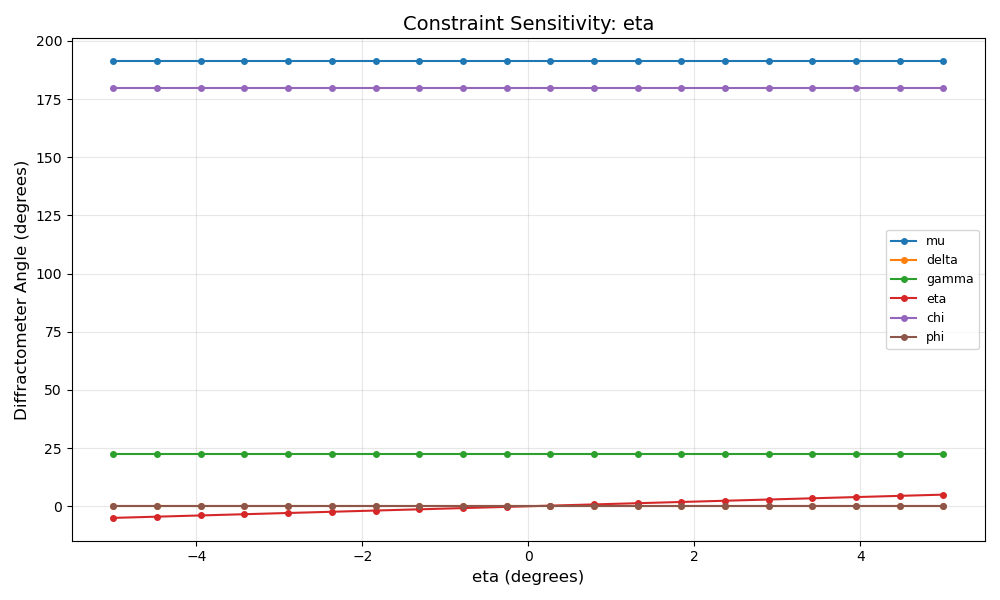

In [10]:
%debug

> /Users/hello/miniforge3/envs/ana310/lib/python3.10/site-packages/pandas/core/indexes/base.py(5401)__getitem__()
   5399             # GH#44051 exclude bool, which would return a 2d ndarray
   5400             key = com.cast_scalar_indexer(key)
-> 5401             return getitem(key)
   5402 
   5403         if isinstance(key, slice):



ipdb>  u


> /Users/hello/miniforge3/envs/ana310/lib/python3.10/site-packages/matplotlib/table.py(828)table()
    826             table.add_cell(0, col,
    827                            width=colWidths[col], height=height,
--> 828                            text=colLabels[col], facecolor=colColours[col],
    829                            loc=colLoc)
    830 



ipdb>  col


4


...

ipdb>  angles_df


                mu  delta      gamma  eta    chi  phi      theta     ttheta  \
sol. 0  191.259224    0.0  22.518447  0.0  180.0  0.0  11.259224  22.518447   
sol. 1   11.259224    0.0  22.518447  0.0    0.0  0.0  11.259224  22.518447   
sol. 2  -11.259224    0.0 -22.518447  0.0  180.0  0.0  11.259224  22.518447   
sol. 3 -191.259224    0.0 -22.518447  0.0    0.0  0.0  11.259224  22.518447   

          qaz      alpha           naz   tau           psi       beta  \
sol. 0    0.0  78.740776  1.800000e+02  90.0 -1.800000e+02 -78.740776   
sol. 1    0.0 -78.740776  2.007873e-46  90.0 -3.920336e-47  78.740776   
sol. 2  180.0 -78.740776  1.800000e+02  90.0  0.000000e+00  78.740776   
sol. 3  180.0  78.740776  2.007873e-46  90.0  1.800000e+02 -78.740776   

           betain    betaout  
sol. 0  11.259224  11.259224  
sol. 1  11.259224  11.259224  
sol. 2  11.259224  11.259224  
sol. 3  11.259224  11.259224  


ipdb>  angles_df.keys()


Index(['mu', 'delta', 'gamma', 'eta', 'chi', 'phi', 'theta', 'ttheta', 'qaz',
       'alpha', 'naz', 'tau', 'psi', 'beta', 'betain', 'betaout'],
      dtype='object')


ipdb>  q


In [4]:
# Calculate structure factor
F = crystal.calc_structure_factor((0, 0, 1), 8048.0)
print(f"Structure factor F(001) = {F}")

Structure factor F(001) = (7.291157631497841+0.0077356228806806995j)
